# Conditional interactions and scenario support

Inspect map, agent, map–agent, composition, support, uncertainty, and teammate-agent swap behavior.

This notebook is generated from immutable, hash-manifested artifacts. Any
counterfactual agent or composition result is predictive/associational,
not a causal estimate.

In [1]:
from pathlib import Path

SNAPSHOT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2")
DEVELOPMENT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full")
CONFIRMATION = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation")
SCORING_V3 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3")
SCORING_V2 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v2")
SCORING_V1 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots")
SCORING = SCORING_V3 if SCORING_V3.exists() else (SCORING_V2 if SCORING_V2.exists() else SCORING_V1)

print("snapshot:", SNAPSHOT)
print("development:", DEVELOPMENT if DEVELOPMENT.exists() else "not supplied")
print("confirmation:", CONFIRMATION if CONFIRMATION.exists() else "not available")
print("scoring:", SCORING if SCORING.exists() else "not available")

snapshot: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2
development: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full
confirmation: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation
scoring: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ratings = pd.read_parquet(SCORING / "player_ratings.parquet")
scenarios = pd.read_parquet(SCORING / "scenario_comparisons.parquet")
natural = pd.read_parquet(DEVELOPMENT / "associational" / "teammate_agent_swap_summary.parquet")

support = ratings.groupby("support").agg(
    rows=("player_id", "size"),
    mean_sd=("standard_deviation", "mean"),
    median_sd=("standard_deviation", "median"),
).sort_values("mean_sd")
display(support)
display(ratings.groupby(["view", "support"]).size().unstack(fill_value=0))

,rows,mean_sd,median_sd
support,,,
observed,1163,0.262822,0.262839
partially-pooled,4390,0.263389,0.263594
extrapolated,52047,0.265515,0.265515


support,extrapolated,observed,partially-pooled
view,,,
agent,6700,5,255
map,1631,0,49
map-agent,43483,1158,4079
overall,233,0,7


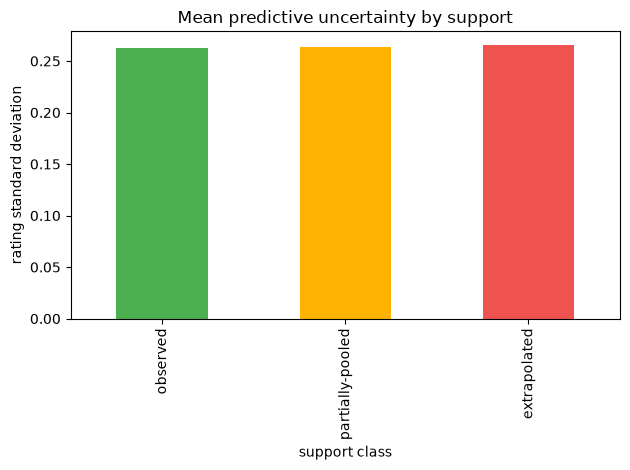

,scenarios,mean_performance_delta,mean_abs_performance_delta,mean_abs_win_probability_delta,median_delta_uncertainty
change_type,,,,,
focal_agent,1680,-0.000048,0.006177,0.000121,0.220841
teammate_agent,1680,0.000000,0.000000,0.000000,0.221702


,map_name,baseline_teammate_agent,alternative_teammate_agent,pairs,players,mean_focal_performance_delta,sd_focal_performance_delta,mean_team_round_margin_delta,standard_error,interval95_low,interval95_high,interpretation
0,Ascent,cypher,killjoy,29,29,4.159895,9.425907,0.325146,1.750347,0.729215,7.590575,associational; not causal
1,Lotus,neon,raze,28,24,-0.145250,10.621379,-0.039303,2.007252,-4.079463,3.788964,associational; not causal
2,Haven,neon,jett,24,24,-1.310684,13.958539,-0.020623,2.849275,-6.895263,4.273895,associational; not causal
3,Split,astra,omen,24,24,7.822420,10.999624,0.390710,2.245289,3.421653,12.223186,associational; not causal
4,Fracture,raze,neon,20,20,3.114469,7.335665,0.240119,1.640304,-0.100528,6.329465,associational; not causal
...,...,...,...,...,...,...,...,...,...,...,...,...
281,Sunset,viper,cypher,4,4,12.400000,5.348875,0.383333,2.674438,7.158102,17.641898,associational; not causal
282,Pearl,killjoy,sova,3,3,-2.900000,13.295770,-0.166667,7.676316,-17.945580,12.145580,associational; not causal
283,Split,cypher,kayo,3,3,-0.573913,8.968300,-0.260870,5.177850,-10.722499,9.574673,associational; not causal
284,Split,yoru,skye,3,3,18.640404,10.927436,0.626263,6.308958,6.274846,31.005962,associational; not causal


In [3]:
order = [value for value in ("observed", "partially-pooled", "extrapolated") if value in support.index]
ax = support.loc[order, "mean_sd"].plot.bar(
    title="Mean predictive uncertainty by support", color=["#4caf50", "#ffb300", "#ef5350"][:len(order)]
)
ax.set(xlabel="support class", ylabel="rating standard deviation")
plt.tight_layout()
plt.show()

scenario_summary = scenarios.groupby("change_type").agg(
    scenarios=("player_id", "size"),
    mean_performance_delta=("performance_delta", "mean"),
    mean_abs_performance_delta=("performance_delta", lambda values: values.abs().mean()),
    mean_abs_win_probability_delta=("team_win_probability_delta", lambda values: values.abs().mean()),
    median_delta_uncertainty=("uncertainty_of_delta", "median"),
)
display(scenario_summary)
display(natural)

Exact five-agent lineups are not assigned independent coefficients.
Shared player–agent, role, pair, focal-response, and pooled interaction
terms provide estimates for unseen cells. Swap deltas hold recorded
inputs fixed but remain associational because agent choices are strategic.